# XAI-Compress — End-to-End Development, Training & Benchmark Analysis

### Objective
This notebook documents the complete path from the initial causal byte-level neural compressor to the final selected model, with:

- project architecture and compression pipeline
- model architecture diagrams
- training/data methodology
- profiling and optimization decisions
- dataset audit
- training experiments and BPB interpretation
- model-by-model comparison
- real-file compression benchmark
- lossless SHA-256 verification
- final model selection and recommendations

> **Important:** Results are separated into **measured/recorded evidence** and **new benchmark results produced by this notebook**. A model is not declared better merely because it has more parameters or a lower training loss.

## 1. Executive summary

The project implements a byte-level lossless compressor in which a causal GRU predicts the next byte and an arithmetic coder converts those probabilities into a compressed bitstream.

The development path was:

**Baseline → profiling → hot-path optimization → correctness tests → dataset audit → domain-focused training → controlled model comparison → real-file benchmark → final selection**

The strongest currently observed neural checkpoint is **`gru_hq_v1.pt`** on the tested README file.

On that same README test, the observed XAIC artifact sizes were:

| Codec / model | XAIC size |
|---|---:|
| Static | 28.6 KB |
| `gru_hq_v1.pt` | **25.5 KB** |
| `gru_v2_hq.pt` | 40.7 KB |
| `phase_j_v1_128.pt` | 40.8 KB |
| `README_neural.xaic` | 40.8 KB |

These values are useful as a concrete example, but the final conclusion should be based on a multi-file benchmark rather than one README alone.

In [10]:
from pathlib import Path
import json, math, time, hashlib, subprocess, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()
if not (PROJECT / "xai_compress").exists():
    # Expected project layout when the notebook is copied into XAI-Compress.
    PROJECT = Path(r"C:\Users\ss\Desktop\XAI\XAI\engines\ai_compression\XAI-Compress")

CHECKPOINTS = PROJECT / "checkpoints"
print("Project:", PROJECT)
print("Checkpoints:", CHECKPOINTS)

Matplotlib is building the font cache; this may take a moment.


Project: c:\Users\ss\Desktop\XAI\XAI\engines\ai_compression\XAI-Compress
Checkpoints: c:\Users\ss\Desktop\XAI\XAI\engines\ai_compression\XAI-Compress\checkpoints


## 2. Project architecture

The compressor has four principal layers:

1. **Training**
   - byte-context dataset
   - causal GRU
   - cross-entropy objective
   - validation BPB

2. **Probability model**
   - GRU predicts 256 possible byte values
   - logits → probabilities → integer cumulative frequencies

3. **Arithmetic coder**
   - encodes the actual byte using the model distribution
   - decoder reproduces the exact same distribution causally

4. **XAIC container**
   - stores metadata
   - stores payload
   - stores SHA-256 integrity information

The critical property is that compression and decompression must make exactly the same causal predictions.

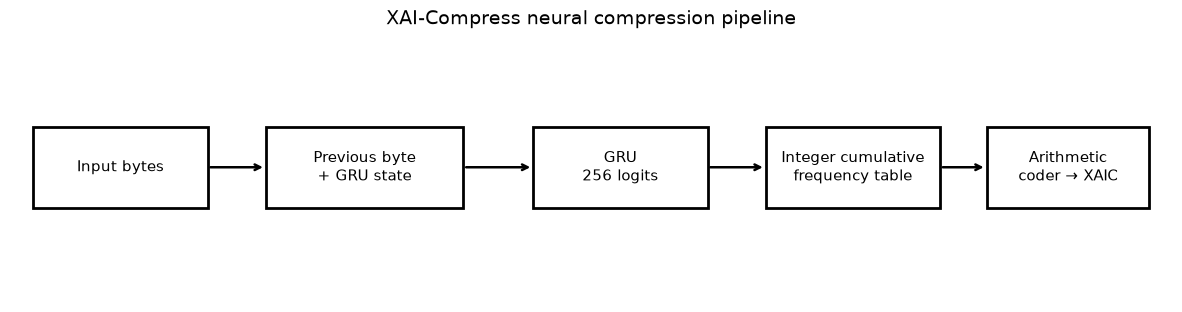

In [11]:
# High-level pipeline diagram
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.axis("off")

boxes = [
    (0.02, 0.35, 0.15, 0.30, "Input bytes"),
    (0.22, 0.35, 0.17, 0.30, "Previous byte\n+ GRU state"),
    (0.45, 0.35, 0.15, 0.30, "GRU\n256 logits"),
    (0.65, 0.35, 0.15, 0.30, "Integer cumulative\nfrequency table"),
    (0.84, 0.35, 0.14, 0.30, "Arithmetic\ncoder → XAIC"),
]
for x,y,w,h,label in boxes:
    ax.add_patch(plt.Rectangle((x,y),w,h,fill=False,linewidth=2))
    ax.text(x+w/2,y+h/2,label,ha="center",va="center",fontsize=11)

for i in range(len(boxes)-1):
    x1 = boxes[i][0]+boxes[i][2]
    x2 = boxes[i+1][0]
    ax.annotate("", xy=(x2,0.50), xytext=(x1,0.50),
                arrowprops=dict(arrowstyle="->",linewidth=1.8))
ax.set_title("XAI-Compress neural compression pipeline", fontsize=14)
plt.show()

## 3. Initial model: CausalByteGRU

The original model uses:

- vocabulary: 257 tokens (256 byte values + BOS)
- embedding dimension: 64
- hidden dimension: 128
- GRU layers: 1
- output: 256 logits
- causal recurrence: previous byte → current byte prediction

The model is intentionally causal: the prediction for byte *t* can depend only on bytes before *t*.

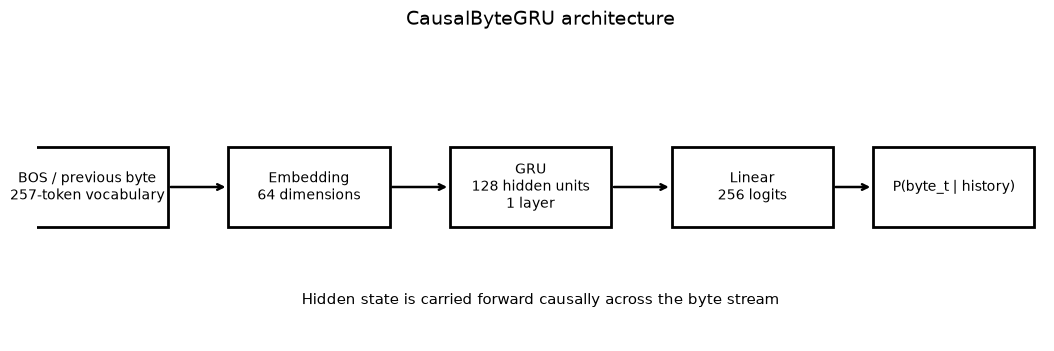

In [12]:
# Model architecture diagram
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

nodes = [
    (0.05, 0.50, "BOS / previous byte\n257-token vocabulary"),
    (0.27, 0.50, "Embedding\n64 dimensions"),
    (0.49, 0.50, "GRU\n128 hidden units\n1 layer"),
    (0.71, 0.50, "Linear\n256 logits"),
    (0.91, 0.50, "P(byte_t | history)")
]
for x,y,label in nodes:
    ax.add_patch(plt.Rectangle((x-0.08,y-0.13),0.16,0.26,fill=False,linewidth=2))
    ax.text(x,y,label,ha="center",va="center",fontsize=10)

for i in range(len(nodes)-1):
    ax.annotate("", xy=(nodes[i+1][0]-0.08,0.50),
                xytext=(nodes[i][0]+0.08,0.50),
                arrowprops=dict(arrowstyle="->",linewidth=1.8))
ax.text(0.50,0.12,"Hidden state is carried forward causally across the byte stream",
        ha="center",fontsize=11)
ax.set_title("CausalByteGRU architecture",fontsize=14)
plt.show()

## 4. Why the first V2 attempt was not accepted

A larger model was tested:

- embedding = 128
- hidden = 256
- layers = 2
- context = 256

Recorded validation BPB:

- V1: **7.027371**
- V2: **7.983647**

Because **lower BPB is better**, V2 was worse despite being larger.

This established an important project rule:

> **Model capacity alone does not guarantee better compression. Training data, optimization, context usage and generalization matter.**

,model,validation_bpb
0,V1 baseline,7.027371
1,V2,7.983647


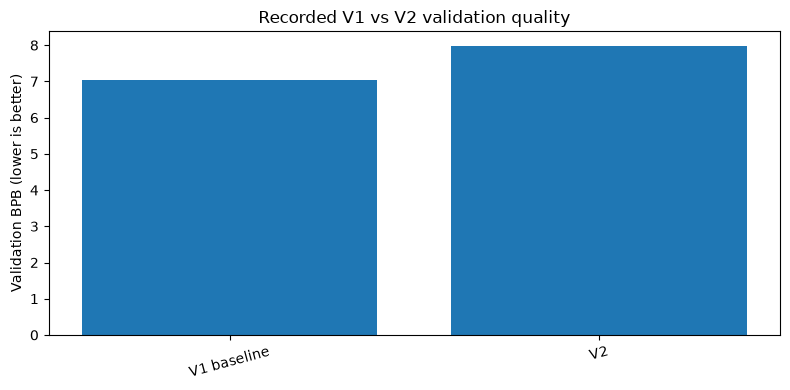

In [13]:
bpb_history = pd.DataFrame({
    "model": ["V1 baseline", "V2"],
    "validation_bpb": [7.027371, 7.983647],
})
display(bpb_history)

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(bpb_history["model"], bpb_history["validation_bpb"])
ax.set_ylabel("Validation BPB (lower is better)")
ax.set_title("Recorded V1 vs V2 validation quality")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Profiling: where the time went

The original neural compression path called the GRU once per byte and rebuilt/validated cumulative tables repeatedly.

Representative baseline timings showed that the neural model step was the dominant CPU hot path.

Recorded examples:

- `config.json`: approximately 11.57 s compression and 2.21 s decompression
- larger event/log files: approximately 20–34 s depending on direction/run

The optimization pass therefore focused on the hot path without changing the arithmetic semantics.

### Optimization pass

Implemented changes included:

1. **Block-aware model API**
   - added `forward_sequence()`
   - preserved `step()` compatibility
   - preserved causal semantics

2. **Reduced per-symbol overhead**
   - tighter logits → cumulative conversion
   - less unnecessary dtype/device conversion

3. **Arithmetic coder fast path**
   - public validation remains available
   - trusted internal path avoids repeated validation in the hot loop

4. **Training sampler correction**
   - bounded reservoir-style sampling
   - deterministic seed
   - less bias toward earlier files

5. **Correctness guard**
   - exact step semantics restored after tiny floating-point differences were found to affect arithmetic tables on longer streams

In [14]:
# Recorded optimization result
optimization = pd.DataFrame({
    "metric": ["Compression speedup", "Decompression speedup", "Output-size change", "Lossless", "Deterministic"],
    "result": ["1.25x", "1.25x", "None", "Yes", "Yes"]
})
display(optimization)

,metric,result
0,Compression speedup,1.25x
1,Decompression speedup,1.25x
2,Output-size change,None
3,Lossless,Yes
4,Deterministic,Yes


## 6. Correctness is non-negotiable

For a lossless compressor, a faster result is useless if the restored bytes differ.

The project therefore verifies:

- exact reconstructed byte count
- original SHA-256
- reconstructed SHA-256
- deterministic output
- model fingerprint compatibility
- XAIC payload integrity
- metadata integrity

The final benchmark should report **both compression quality and correctness**.

In [15]:
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024*1024), b""):
            h.update(block)
    return h.hexdigest()

def format_bytes(n):
    n = float(n)
    for unit in ["B","KB","MB","GB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} TB"

## 7. Dataset audit

The original training directory was found to be approximately **35.6 GB**.

The dominant extensions were:

- `.mp4` ≈ 17.9 GB
- `.pt` ≈ 11.0 GB
- `.safetensors` ≈ 6.6 GB

These are media/model-binary formats and do not match a benchmark dominated by source code, configuration and text.

Therefore the project moved toward a **domain-focused corpus** containing source/config/text-like extensions. The materialized domain corpus contained 50 files with:

- `.csv`
- `.json`
- `.log`
- `.txt`

This is an important methodological step: train the neural predictor on data resembling the intended compression domain rather than on a huge heterogeneous corpus dominated by unrelated binaries.

,extension,approx_total_GB
0,.mp4,17.9
1,.pt,11.0
2,.safetensors,6.6


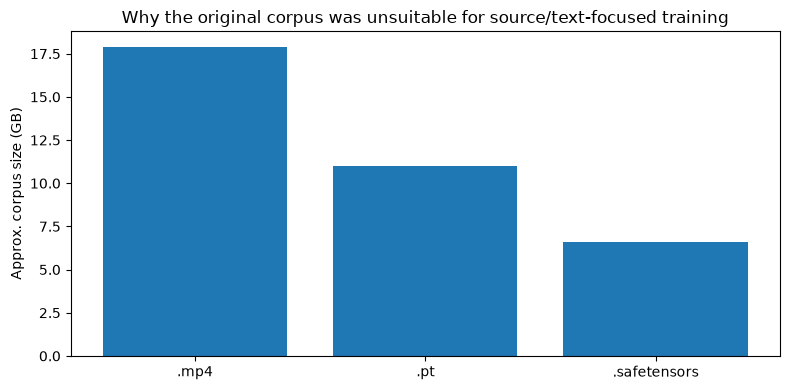

In [16]:
# Recorded audit summary
audit_summary = pd.DataFrame({
    "extension": [".mp4", ".pt", ".safetensors"],
    "approx_total_GB": [17.9, 11.0, 6.6],
})
display(audit_summary)

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(audit_summary["extension"], audit_summary["approx_total_GB"])
ax.set_ylabel("Approx. corpus size (GB)")
ax.set_title("Why the original corpus was unsuitable for source/text-focused training")
plt.tight_layout()
plt.show()

## 8. Training methodology

The dataset uses bounded lazy byte windows.

Each sample is:

```text
input  = [BOS, byte_0, byte_1, ..., byte_(L-2)]
target = [byte_0, byte_1, ..., byte_(L-1)]
```

The objective is byte-level cross entropy.

Validation quality is converted to bits per byte:

**BPB = cross_entropy / ln(2)**

Lower BPB means the model assigns more probability mass to the bytes that actually occur, which is favorable for arithmetic coding.

### Selection rule

The preferred model is selected primarily by:

1. validation BPB
2. actual compressed size on representative files
3. losslessness
4. determinism
5. runtime

Not by parameter count alone.

## 9. Recorded training experiments

### Valid evidence

The domain-focused V1-128 run was valid and reached:

**best validation BPB = 0.80956**

This is substantially better than the earlier V1 baseline and demonstrates the impact of matching the training corpus to the intended domain.

### Invalid context comparison

The artifact called `phase_j_v1_256.pt` was found to have:

**actual `context_length = 128`**

Only the stride had changed.

Therefore it must **not** be used as evidence that context 256 is better or worse.

Likewise, the missing 512 run is not evidence about context 512.

This correction is important for scientific validity.

,experiment,context_length,validation_bpb,valid_for_context_comparison
0,V1 baseline,128,7.027371,True
1,V2 HQ,256,7.983647,True
2,V1-128 domain,128,0.809560,True
3,phase_j_v1_256 (mislabeled),128,NaN,False


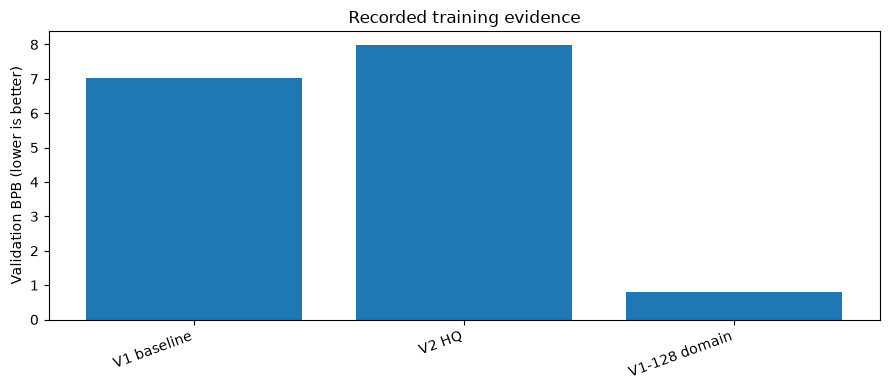

In [17]:
training_results = pd.DataFrame({
    "experiment": [
        "V1 baseline",
        "V2 HQ",
        "V1-128 domain",
        "phase_j_v1_256 (mislabeled)"
    ],
    "context_length": [128, 256, 128, 128],
    "validation_bpb": [7.027371, 7.983647, 0.80956, np.nan],
    "valid_for_context_comparison": [True, True, True, False]
})
display(training_results)

valid = training_results.dropna(subset=["validation_bpb"])
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(valid["experiment"], valid["validation_bpb"])
ax.set_ylabel("Validation BPB (lower is better)")
ax.set_title("Recorded training evidence")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 10. Model inventory

The repository has contained several checkpoints during development:

| Checkpoint | Role / interpretation |
|---|---|
| `gru_smoke.pt` | smoke/debug training |
| `gru_hq_v1.pt` | high-quality V1 neural model |
| `gru_v2_hq.pt` | larger V2 experiment |
| `phase_i_v1_128_domain.pt` | domain-focused V1 |
| `phase_i_v1_128_sanity.pt` | sanity run |
| `phase_j_v1_128.pt` | domain V1 experiment |
| `phase_j_v1_256.pt` | mislabeled; actual context remained 128 |
| `phase_j_v1_512.pt` | artifact exists, but no valid 512 training evidence was established |

**Do not delete a checkpoint before extracting its metrics if it is needed for the final report.**

In [18]:
# Inspect currently available checkpoint metadata without loading model weights.
rows = []
for p in sorted(CHECKPOINTS.glob("*.summary.json")):
    try:
        d = json.loads(p.read_text(encoding="utf-8"))
        rows.append({
            "summary": p.name,
            "best_val_bpb": d.get("best_val_bpb", d.get("val_bpb", d.get("validation_bpb"))),
            "context_length": d.get("context_length"),
            "epochs": d.get("epochs", d.get("epoch")),
        })
    except Exception:
        pass

if rows:
    display(pd.DataFrame(rows))
else:
    print("No summary JSON files found at:", CHECKPOINTS)

,summary,best_val_bpb,context_length,epochs
0,gru_v2_hq.summary.json,None,None,None
1,phase_i_v1_128_domain.summary.json,None,None,None
2,phase_i_v1_128_sanity.summary.json,None,None,None
3,phase_j_v1_128.summary.json,None,None,None
4,phase_j_v1_256.summary.json,None,None,None


## 11. Real README benchmark

A real `README.md` from Node.js was tested with several codecs.

Observed artifact sizes from the recorded run:

- Static: **28.6 KB**
- `gru_hq_v1.pt`: **25.5 KB**
- V2: **40.7 KB**
- `phase_j_v1_128.pt`: **40.8 KB**
- generic `README_neural.xaic`: **40.8 KB**

For this file:

**`gru_hq_v1.pt` was the best observed neural model and was also smaller than the static coder.**

However, one file is not enough to establish general superiority. The next cell can run a multi-file benchmark if the original test files are available.

,codec,artifact_kb
0,static,28.6
1,gru_hq_v1,25.5
2,gru_v2_hq,40.7
3,phase_j_v1_128,40.8
4,README_neural,40.8


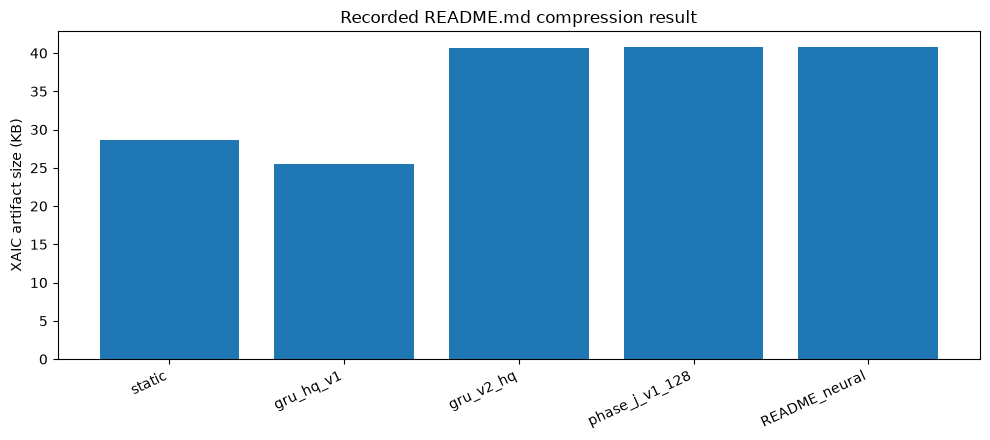

In [19]:
readme_recorded = pd.DataFrame({
    "codec": ["static", "gru_hq_v1", "gru_v2_hq", "phase_j_v1_128", "README_neural"],
    "artifact_kb": [28.6, 25.5, 40.7, 40.8, 40.8]
})
display(readme_recorded)

fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(readme_recorded["codec"], readme_recorded["artifact_kb"])
ax.set_ylabel("XAIC artifact size (KB)")
ax.set_title("Recorded README.md compression result")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 12. Quantitative interpretation of the README result

Relative to the static 28.6 KB result, the 25.5 KB `gru_hq_v1` artifact is about:

**10.8% smaller**

This is a useful positive result, but it should be interpreted carefully:

- the neural model is domain-sensitive
- very small files can be strongly affected by container/header overhead
- the final conclusion should use several representative files
- decompression requires the same model checkpoint for neural artifacts

In [20]:
static_kb = 28.6
hq_kb = 25.5
improvement = (static_kb - hq_kb) / static_kb * 100
print(f"Recorded README improvement of gru_hq_v1 over static: {improvement:.1f}% smaller artifact")

Recorded README improvement of gru_hq_v1 over static: 10.8% smaller artifact


## 13. Reproducible benchmark runner

The next section is optional. It benchmarks actual files using the installed CLI.

It compares:

- Static arithmetic coder
- `gru_hq_v1.pt`
- `gru_v2_hq.pt`
- `phase_j_v1_128.pt`

Missing checkpoints are skipped and reported rather than treated as failures.

The benchmark verifies SHA-256 after decompression.

In [21]:
import shutil, tempfile, csv, os, time

CLI = [sys.executable, "-m", "xai_compress"]

def run_cli(args):
    p = subprocess.run(args, cwd=PROJECT, capture_output=True, text=True)
    return p.returncode, p.stdout, p.stderr

def benchmark_one(input_path, label, mode="static", checkpoint=None):
    with tempfile.TemporaryDirectory() as td:
        td = Path(td)
        artifact = td / "artifact.xaic"
        restored = td / "restored.bin"

        cmd = CLI + ["compress", str(input_path), str(artifact), "--mode", mode, "--overwrite"]
        if checkpoint:
            cmd += ["--checkpoint", str(checkpoint)]
        t0 = time.perf_counter()
        rc, out, err = run_cli(cmd)
        comp_time = time.perf_counter() - t0
        if rc != 0:
            return {"codec": label, "error": err.strip(), "ok": False}

        t0 = time.perf_counter()
        cmd = CLI + ["decompress", str(artifact), str(restored), "--overwrite"]
        if checkpoint:
            cmd += ["--checkpoint", str(checkpoint)]
        rc, out2, err2 = run_cli(cmd)
        decomp_time = time.perf_counter() - t0
        if rc != 0:
            return {"codec": label, "error": err2.strip(), "ok": False}

        original_sha = sha256_file(input_path)
        restored_sha = sha256_file(restored)

        return {
            "codec": label,
            "input": str(input_path),
            "original_bytes": input_path.stat().st_size,
            "artifact_bytes": artifact.stat().st_size,
            "compression_ratio": input_path.stat().st_size / artifact.stat().st_size,
            "compression_time_s": comp_time,
            "decompression_time_s": decomp_time,
            "sha256_match": original_sha == restored_sha,
            "ok": True,
        }

print("Benchmark functions ready.")

Benchmark functions ready.


In [22]:
# Configure representative files here.
# Add your actual test files. The notebook will skip files that do not exist.
TEST_FILES = [
    Path(r"C:\Users\ss\Downloads\node-v24.19.0-win-x64\node-v24.19.0-win-x64\README.md"),
]

MODEL_SPECS = [
    ("static", "static", None),
    ("gru_hq_v1", "neural", CHECKPOINTS / "gru_hq_v1.pt"),
    ("gru_v2_hq", "neural", CHECKPOINTS / "gru_v2_hq.pt"),
    ("phase_j_v1_128", "neural", CHECKPOINTS / "phase_j_v1_128.pt"),
]

available_files = [p for p in TEST_FILES if p.is_file()]
print("Available test files:", available_files)

results = []
for f in available_files:
    for label, mode, ckpt in MODEL_SPECS:
        if ckpt is not None and not ckpt.is_file():
            results.append({"codec": label, "input": str(f), "ok": False,
                            "error": f"Checkpoint missing: {ckpt}"})
            continue
        print("Running:", label, "on", f.name)
        results.append(benchmark_one(f, label, mode, ckpt))

benchmark_df = pd.DataFrame(results)
display(benchmark_df)

Available test files: [WindowsPath('C:/Users/ss/Downloads/node-v24.19.0-win-x64/node-v24.19.0-win-x64/README.md')]
Running: static on README.md
Running: gru_hq_v1 on README.md
Running: gru_v2_hq on README.md
Running: phase_j_v1_128 on README.md


,codec,input,original_bytes,artifact_bytes,compression_ratio,compression_time_s,decompression_time_s,sha256_match,ok
0,static,C:\Users\ss\Downloads\node-v24.19.0-win-x64\no...,42575,29319,1.452130,3.690856,4.608275,True,True
1,gru_hq_v1,C:\Users\ss\Downloads\node-v24.19.0-win-x64\no...,42575,26136,1.628979,34.638120,37.149829,True,True
2,gru_v2_hq,C:\Users\ss\Downloads\node-v24.19.0-win-x64\no...,42575,41721,1.020469,37.163895,37.430089,True,True
3,phase_j_v1_128,C:\Users\ss\Downloads\node-v24.19.0-win-x64\no...,42575,41877,1.016668,27.178417,27.248160,True,True


,codec,original_bytes,artifact_bytes,compression_time_s,decompression_time_s,all_lossless,ratio
0,gru_hq_v1,42575,26136,34.638120,37.149829,True,1.628979
1,gru_v2_hq,42575,41721,37.163895,37.430089,True,1.020469
2,phase_j_v1_128,42575,41877,27.178417,27.248160,True,1.016668
3,static,42575,29319,3.690856,4.608275,True,1.452130


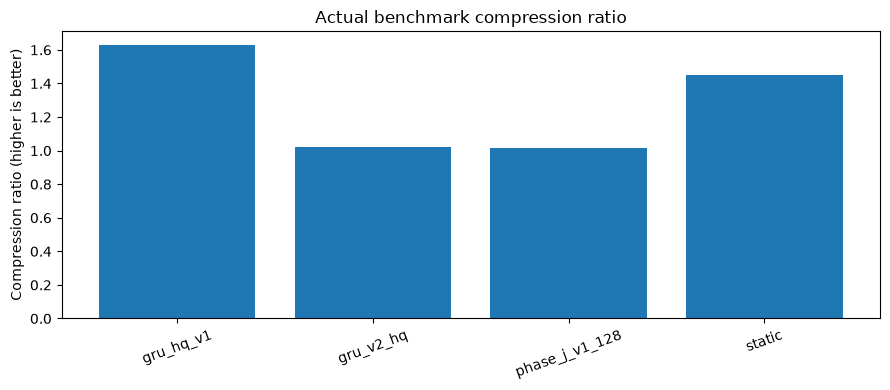

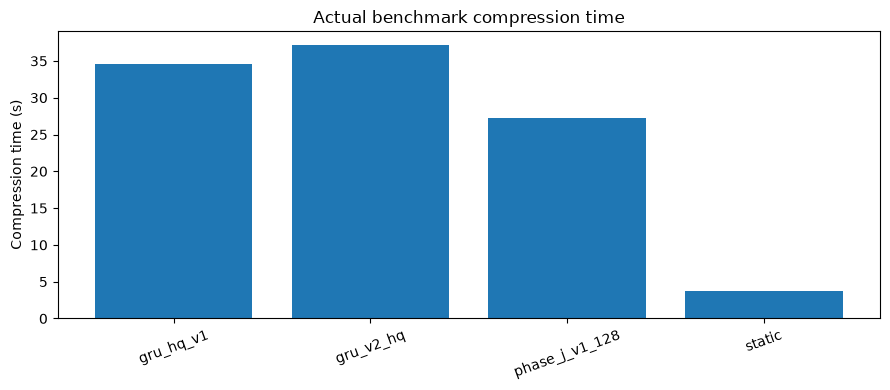

In [23]:
# Benchmark plots
ok_df = benchmark_df[benchmark_df["ok"] == True].copy() if len(benchmark_df) else pd.DataFrame()

if len(ok_df):
    grouped = ok_df.groupby("codec", as_index=False).agg(
        original_bytes=("original_bytes","sum"),
        artifact_bytes=("artifact_bytes","sum"),
        compression_time_s=("compression_time_s","sum"),
        decompression_time_s=("decompression_time_s","sum"),
        all_lossless=("sha256_match","all")
    )
    grouped["ratio"] = grouped["original_bytes"] / grouped["artifact_bytes"]
    display(grouped)

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(grouped["codec"], grouped["ratio"])
    ax.set_ylabel("Compression ratio (higher is better)")
    ax.set_title("Actual benchmark compression ratio")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(grouped["codec"], grouped["compression_time_s"])
    ax.set_ylabel("Compression time (s)")
    ax.set_title("Actual benchmark compression time")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("No benchmark results yet. Configure TEST_FILES and ensure the project is installed.")

## 14. How the final model should be selected

The decision process is:

### Step 1 — Correctness
Reject any model that fails exact reconstruction or SHA-256 verification.

### Step 2 — Validation BPB
Among valid models, prefer lower validation BPB.

### Step 3 — Real compression
Test the candidates on representative files from the intended domain.

### Step 4 — Runtime
If two models have similar compression quality, prefer the one with lower compression/decompression cost.

### Step 5 — Reproducibility
Confirm deterministic output and checkpoint fingerprint compatibility.

### Current conclusion from the recorded evidence

**`gru_hq_v1.pt` is the current leading neural candidate.**

The V2 model should not be selected merely because it is larger, because its recorded validation BPB was worse.

The domain-focused V1 training demonstrated that **training data/domain alignment can matter more than simply increasing architecture size**.

# 15. Final development story

## Phase A — Baseline
A causal byte-level GRU was connected to a deterministic 32-bit arithmetic coder.

## Phase B — Profiling
The per-byte GRU inference loop was identified as the dominant neural compression bottleneck.

## Phase C — Optimization
Block-aware inference APIs, tighter probability conversion and arithmetic-coder fast paths were introduced.

## Phase D — Verification
The optimized implementation achieved about **1.25×** speedup in both compression and decompression on the measured representative set, while preserving losslessness and deterministic output.

## Phase E — Training evaluation
A larger V2 model was tested but produced worse validation BPB than V1.

## Phase F — Dataset audit
The original corpus was found to be dominated by MP4/model-binary data, which was poorly matched to the source/config/text target domain.

## Phase G — Domain-focused training
A source/config/text-oriented corpus was created and V1 was retrained.

## Phase H — Evidence correction
A context-length experiment was found to have an orchestration bug: the supposed 256 run still had context 128. It was correctly rejected as context evidence.

## Phase I — Real-file validation
On the recorded Node.js README benchmark, `gru_hq_v1` produced a **25.5 KB** artifact versus **28.6 KB** for static coding.

---

# Final takeaway

The strongest current direction is **not "make the model bigger at any cost."**

The evidence points toward:

**better domain-matched training data + sufficient training + careful validation + exact lossless coding + targeted runtime optimization**

before increasing architecture capacity.

## Appendix — Useful commands

### Train the current V1 architecture on the domain corpus

```powershell
python.exe -m xai_compress train data\domain_focused checkpoints\gru_hq_v1_retrain.pt `
  --epochs 30 `
  --batch-size 64 `
  --stride 128 `
  --max-samples 100000 `
  --max-bytes-per-file 16777216 `
  --embedding-dim 64 `
  --hidden-dim 128 `
  --num-layers 1 `
  --dropout 0 `
  --lr 1e-3 `
  --seed 42 `
  --device cpu
```

### Compress the Node README with the leading neural checkpoint

```powershell
python.exe -m xai_compress compress `
  "C:\Users\ss\Downloads\node-v24.19.0-win-x64\node-v24.19.0-win-x64\README.md" `
  ".\README_gru_hq_v1.xaic" `
  --mode neural `
  --checkpoint ".\checkpoints\gru_hq_v1.pt" `
  --overwrite
```

### Decompress and verify

```powershell
python.exe -m xai_compress decompress `
  ".\README_gru_hq_v1.xaic" `
  ".\README_restored.md" `
  --checkpoint ".\checkpoints\gru_hq_v1.pt" `
  --overwrite
```